# Aktina — Solar Forecast Model Results

**Goal:** predict tomorrow's hourly shortwave radiation (W/m²) in Paphos, so the scheduler can move desalination and pumping into the midday solar-surplus hours.

**Data:** Open-Meteo historical weather for Paphos (34.77°N, 32.42°E), hourly, 14 Sep 2024 – 28 Sep 2026, local time (Asia/Nicosia).
**Model:** LightGBM regressor, compared against a *persistence* baseline ("tomorrow at this hour = today at this hour").

In [1]:
import os
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*eval_set.*")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, precision_score, recall_score, f1_score, confusion_matrix
from lightgbm import LGBMRegressor, early_stopping

# run from the repo root so paths match the scripts
if not os.path.exists("data/features.csv"):
    os.chdir("..")

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
BASE_C, MODEL_C, TRUE_C = "#9aa0a6", "#1a73e8", "#202124"
SURPLUS = 600  # W/m², surplus-hour threshold

df = pd.read_csv("data/features.csv", index_col=0, parse_dates=True)
FEATURES = [c for c in df.columns if c != "target"]
print(f"Rows: {len(df):,}   Features: {FEATURES}")
print(f"Period: {df.index.min()} → {df.index.max()}   Missing values: {int(df.isna().sum().sum())}")

Rows: 17,832   Features: ['temperature_2m', 'shortwave_radiation', 'relative_humidity_2m', 'cloud_cover', 'radiation_yesterday', 'hour', 'month']
Period: 2024-09-15 00:00:00 → 2026-09-27 23:00:00   Missing values: 0


## 1. The data: when is there a solar surplus?
Average radiation per hour of day, all year vs summer vs winter. The dashed line is the 600 W/m² surplus threshold.

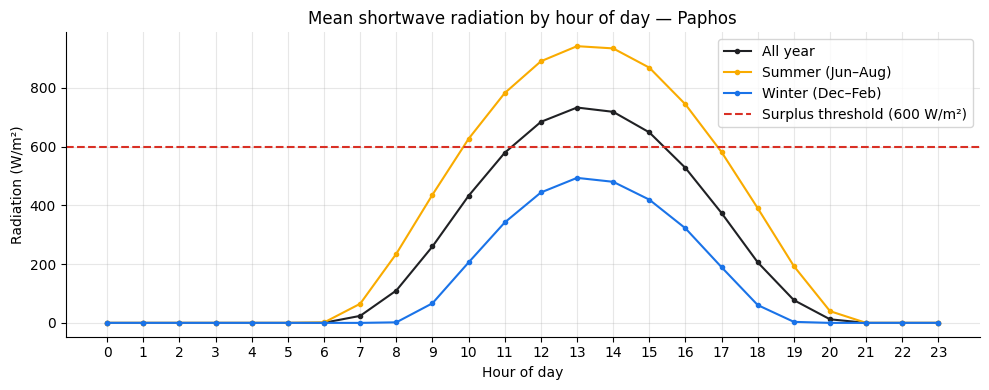

All year          : hours above 600 W/m² → [12, 13, 14, 15]
Summer (Jun–Aug)  : hours above 600 W/m² → [10, 11, 12, 13, 14, 15, 16]
Winter (Dec–Feb)  : hours above 600 W/m² → none


In [2]:
raw = pd.read_csv("data/paphos_weather_data.csv", index_col=0, parse_dates=True)
rad = raw["shortwave_radiation"]
profiles = {
    "All year": rad.groupby(rad.index.hour).mean(),
    "Summer (Jun–Aug)": rad[rad.index.month.isin([6, 7, 8])].groupby(rad[rad.index.month.isin([6, 7, 8])].index.hour).mean(),
    "Winter (Dec–Feb)": rad[rad.index.month.isin([12, 1, 2])].groupby(rad[rad.index.month.isin([12, 1, 2])].index.hour).mean(),
}
fig, ax = plt.subplots()
for (name, s), c in zip(profiles.items(), [TRUE_C, "#f9ab00", "#1a73e8"]):
    ax.plot(s.index, s.values, marker="o", ms=3, label=name, color=c)
ax.axhline(SURPLUS, color="#d93025", ls="--", label=f"Surplus threshold ({SURPLUS} W/m²)")
ax.set(title="Mean shortwave radiation by hour of day — Paphos", xlabel="Hour of day", ylabel="Radiation (W/m²)", xticks=range(24))
ax.legend(); plt.tight_layout(); plt.show()

for name, s in profiles.items():
    hrs = list(s[s > SURPLUS].index)
    print(f"{name:18s}: hours above {SURPLUS} W/m² → {hrs if hrs else 'none'}")

## 2. Time-ordered split (60 / 20 / 20)
No shuffling: the model is always evaluated on a future it has never seen.
- **Train** — learning
- **Validation (cv)** — choosing settings (early stopping)
- **Test** — used **once**, at the end

In [3]:
X, y = df[FEATURES], df["target"]
train_x, rest_x, train_y, rest_y = train_test_split(X, y, test_size=0.4, shuffle=False)
cv_x, test_x, cv_y, test_y = train_test_split(rest_x, rest_y, test_size=0.5, shuffle=False)

pd.DataFrame({
    "rows": [len(train_x), len(cv_x), len(test_x)],
    "from": [s.index.min().date() for s in (train_x, cv_x, test_x)],
    "to":   [s.index.max().date() for s in (train_x, cv_x, test_x)],
}, index=["train", "validation (cv)", "test"])

,rows,from,to
train,10699,2024-09-15,2025-12-04
validation (cv),3566,2025-12-04,2026-05-02
test,3567,2026-05-02,2026-09-27


## 3. Baseline: persistence
"Tomorrow at 13:00 = today at 13:00." Any useful model must beat this.

In [4]:
base_cv   = cv_x["shortwave_radiation"]
base_test = test_x["shortwave_radiation"]
print(f"Baseline MAE  cv:   {mean_absolute_error(cv_y, base_cv):.2f} W/m²")
print(f"Baseline MAE  test: {mean_absolute_error(test_y, base_test):.2f} W/m²")

Baseline MAE  cv:   32.47 W/m²
Baseline MAE  test: 12.26 W/m²


## 4. Model selection on the validation set
LightGBM, learning rate 0.05, up to 1000 trees, early stopping on validation MAE (`l1`) after 50 rounds without improvement.

**Experiment log** (validation MAE, W/m²):

| Version | CV MAE |
|---|---|
| Persistence baseline | 32.47 |
| LightGBM, 7 features, defaults | 29.76 |
| + 24h mean cloud cover & 24h max radiation | 29.82 → *no gain, removed* |
| + clip negative predictions to 0 | 29.67 |
| + early stopping (lr 0.05, metric l1) | **29.34** |

In [5]:
exp_model = LGBMRegressor(n_estimators=1000, learning_rate=0.05, metric="l1", verbose=-1)
exp_model.fit(train_x, train_y, eval_set=[(cv_x, cv_y)],
              callbacks=[early_stopping(50, verbose=False)])
cv_pred = pd.Series(np.clip(exp_model.predict(cv_x), 0, None), index=cv_x.index)
print(f"Best number of trees: {exp_model.best_iteration_}")
print(f"Model MAE cv: {mean_absolute_error(cv_y, cv_pred):.2f} W/m²")

Best number of trees: 148
Model MAE cv: 29.34 W/m²


## 5. Final model and the one-time test
The chosen recipe is retrained on **train + validation** and evaluated **once** on the test set (summer 2026).

In [6]:
try:
    final_model = joblib.load("model/lgbm_radiation.pkl")
    source = "loaded model/lgbm_radiation.pkl"
except Exception as e:
    final_model = LGBMRegressor(n_estimators=148, learning_rate=0.05, metric="l1", verbose=-1)
    final_model.fit(pd.concat([train_x, cv_x]), pd.concat([train_y, cv_y]))
    source = f"retrained (could not load .pkl: {type(e).__name__})"
test_pred = pd.Series(np.clip(final_model.predict(test_x[FEATURES]), 0, None), index=test_x.index)
print(f"Final model: {source}")
print(f"Model MAE test: {mean_absolute_error(test_y, test_pred):.2f} W/m²")

Final model: loaded model/lgbm_radiation.pkl
Model MAE test: 14.27 W/m²


## 6. Results summary
"Daylight only" excludes hours where both the truth and the baseline are 0 (night), which otherwise dilute the error.

In [7]:
def row(name, y_true, base, pred):
    day = (y_true > 0) | (base > 0)
    b, m = mean_absolute_error(y_true, base), mean_absolute_error(y_true, pred)
    bd, mdl = mean_absolute_error(y_true[day], base[day]), mean_absolute_error(y_true[day], pred[day])
    return {"period": name,
            "baseline MAE": round(b, 2), "model MAE": round(m, 2), "change": f"{(m - b) / b:+.1%}",
            "baseline MAE (daylight)": round(bd, 2), "model MAE (daylight)": round(mdl, 2), "change (daylight)": f"{(mdl - bd) / bd:+.1%}"}

results = pd.DataFrame([row("Validation: Dec 2025 – May 2026", cv_y, base_cv, cv_pred),
                        row("Test: May – Sep 2026", test_y, base_test, test_pred)]).set_index("period")
results

,baseline MAE,model MAE,change,baseline MAE (daylight),model MAE (daylight),change (daylight)
period,,,,,,
Validation: Dec 2025 – May 2026,32.47,29.34,-9.6%,66.28,59.47,-10.3%
Test: May – Sep 2026,12.26,14.27,+16.4%,20.57,23.66,+15.1%


### Error by month
Where does the model help, and where does persistence already do well?

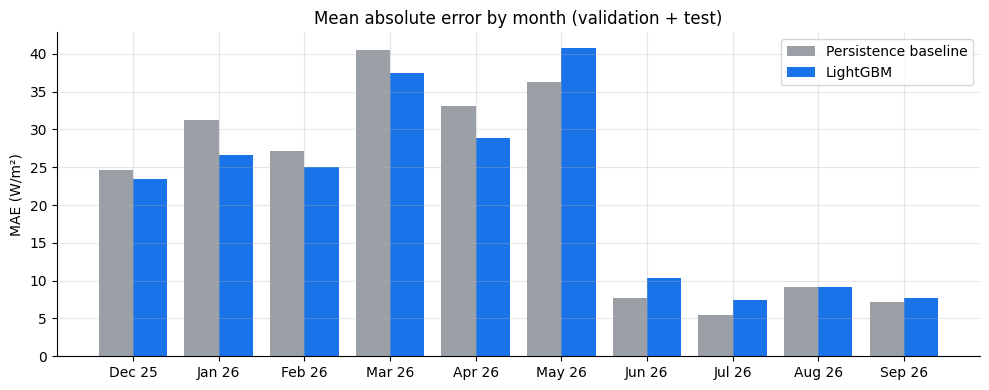

time,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07,2026-08,2026-09
Baseline,24.6,31.2,27.2,40.4,33.1,36.2,7.7,5.4,9.2,7.2
Model,23.5,26.6,25.0,37.4,28.8,40.8,10.3,7.4,9.1,7.7


In [8]:
all_true = pd.concat([cv_y, test_y]); all_base = pd.concat([base_cv, base_test]); all_pred = pd.concat([cv_pred, test_pred])
err = pd.DataFrame({"Baseline": (all_true - all_base).abs(), "Model": (all_true - all_pred).abs()})
monthly = err.groupby(err.index.to_period("M")).mean()

fig, ax = plt.subplots()
x = np.arange(len(monthly)); w = 0.4
ax.bar(x - w/2, monthly["Baseline"], w, label="Persistence baseline", color=BASE_C)
ax.bar(x + w/2, monthly["Model"], w, label="LightGBM", color=MODEL_C)
ax.set_xticks(x, [p.strftime("%b %y") for p in monthly.index])
ax.set(title="Mean absolute error by month (validation + test)", ylabel="MAE (W/m²)")
ax.legend(); plt.tight_layout(); plt.show()
monthly.round(1).T

## 7. Forecast vs reality — one changeable week and one stable week

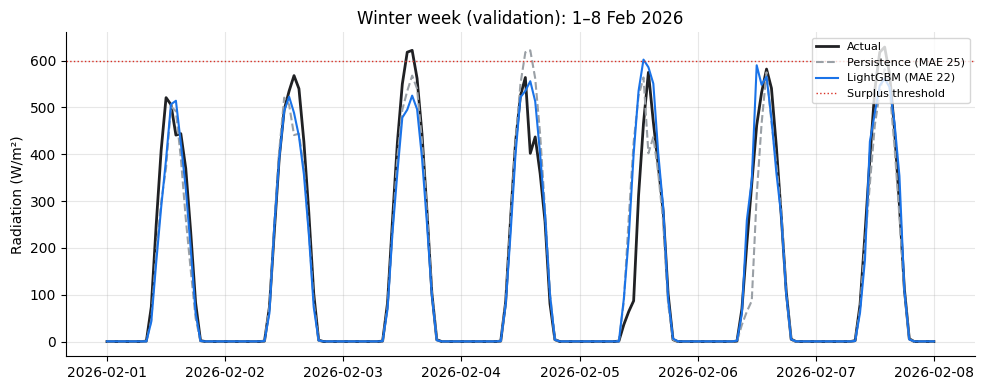

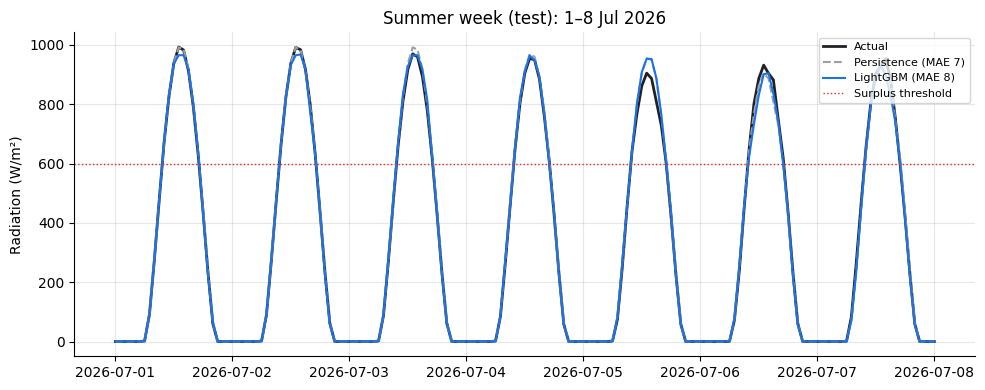

In [9]:
def week_plot(start, title, pred):
    end = pd.Timestamp(start) + pd.Timedelta(days=7)
    t = all_true[start:end]; b = all_base[start:end]; p = pred[start:end]
    fig, ax = plt.subplots()
    ax.plot(t.index, t, color=TRUE_C, lw=2, label="Actual")
    ax.plot(b.index, b, color=BASE_C, ls="--", label=f"Persistence (MAE {mean_absolute_error(t, b):.0f})")
    ax.plot(p.index, p, color=MODEL_C, label=f"LightGBM (MAE {mean_absolute_error(t, p):.0f})")
    ax.axhline(SURPLUS, color="#d93025", ls=":", lw=1, label="Surplus threshold")
    ax.set(title=title, ylabel="Radiation (W/m²)"); ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout(); plt.show()

week_plot("2026-02-01", "Winter week (validation): 1–8 Feb 2026", cv_pred)
week_plot("2026-07-01", "Summer week (test): 1–8 Jul 2026", test_pred)

## 8. What the model relies on
Feature importance by total gain (how much each feature reduced the error across all trees).

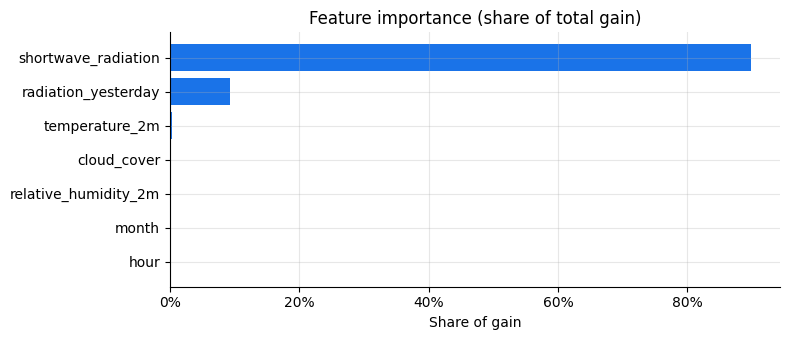

In [10]:
imp = pd.Series(final_model.booster_.feature_importance(importance_type="gain"), index=FEATURES)
imp = (imp / imp.sum()).sort_values()
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(imp.index, imp.values, color=MODEL_C)
ax.set(title="Feature importance (share of total gain)", xlabel="Share of gain")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
plt.tight_layout(); plt.show()

## 9. The decision that matters: surplus hours
The scheduler only needs to know **which hours tomorrow exceed 600 W/m²**. So we also score the forecasts as a yes/no classification.
- **Precision:** of the hours we flagged as surplus, how many really were (avoid running pumps on a cloudy hour).
- **Recall:** of the real surplus hours, how many we caught (avoid wasting free solar).

In [11]:
def surplus_scores(y_true, pred):
    t, p = y_true > SURPLUS, pred > SURPLUS
    return {"precision": precision_score(t, p), "recall": recall_score(t, p), "F1": f1_score(t, p)}

surplus = pd.DataFrame({
    ("Validation", "Baseline"): surplus_scores(cv_y, base_cv),
    ("Validation", "LightGBM"): surplus_scores(cv_y, cv_pred),
    ("Test", "Baseline"): surplus_scores(test_y, base_test),
    ("Test", "LightGBM"): surplus_scores(test_y, test_pred),
}).round(3)
surplus

Validation              Test         
            Baseline LightGBM Baseline LightGBM
precision      0.797    0.814    0.980    0.976
recall         0.797    0.788    0.975    0.955
F1             0.797    0.801    0.978    0.965

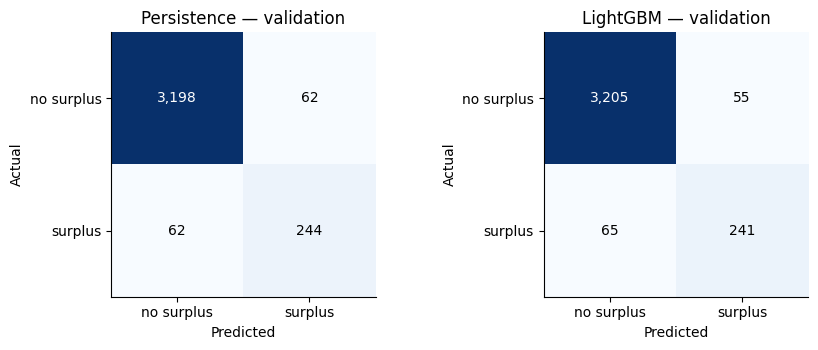

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, (name, pred) in zip(axes, [("Persistence", base_cv), ("LightGBM", cv_pred)]):
    cm = confusion_matrix(cv_y > SURPLUS, pred > SURPLUS)
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks([0, 1], ["no surplus", "surplus"]); ax.set_yticks([0, 1], ["no surplus", "surplus"])
    ax.set(title=f"{name} — validation", xlabel="Predicted", ylabel="Actual"); ax.grid(False)
plt.tight_layout(); plt.show()

## 10. Conclusions

**What works**
- On the changeable **winter–spring** validation period, LightGBM cuts the forecast error by **9.6%** vs persistence (32.47 → 29.34 W/m²), and by **10.3%** on daylight hours only (66.3 → 59.5 W/m²). It wins in every validation month from December to April.
- For the scheduler's actual decision (surplus hour yes/no), the model is on par with persistence in winter–spring (F1 0.80 vs 0.80, slightly higher precision).

**What doesn't (yet)**
- On the stable **summer** test period, persistence is better (12.26 vs 14.27 W/m²). Cyprus summer days are almost identical, so "same as yesterday" is close to perfect, and both approaches catch ~96–98% of surplus hours.
- In winter the *average* hour never reaches 600 W/m², so surplus hours exist only on clear days. That is exactly when a good forecast matters most.

- Feature importance shows the model relies almost entirely on **current radiation** and **yesterday's radiation**; cloud cover, humidity and temperature add very little. Today's observations carry limited information about tomorrow's clouds.

**Takeaway:** the AI adds value when the weather is uncertain; in stable summer conditions persistence is already excellent. A production system should switch between them (or blend them) by season and conditions.

**Next steps**
1. Add **numerical weather forecasts** (Open-Meteo archived forecasts: tomorrow's predicted cloud cover and radiation) as features. This is the information today's observations cannot provide, and the most likely source of a large improvement.
2. A **hybrid** persistence/ML switch, validated on a separate period.
3. More years of training data (currently ~1 year in train), so the model sees several summers and winters.
4. Tune the surplus threshold per season, or link it to actual curtailment data from TSO Cyprus.
